# 공정능력지수(Cpk/Ppk) & SPC 관리도 — 6주차 확장

지금까지의 SECOM 파트는 익명화된 590개 센서로 XGBoost/Isolation Forest 같은 **ML 기반** 이상 탐지를 했다. 이 노트북은 그것과는 다른, **fab 품질관리의 가장 기본 도구**인 SPC(Statistical Process Control) — 관리도와 공정능력지수(Cp/Cpk/Pp/Ppk), Western Electric 룰 — 을 다룬다.

**왜 SECOM이 아니라 공정 시뮬레이터(`simulator/`)에 적용하는가**: Cpk 계산에는 실제 공학 단위와 규격 상하한(USL/LSL)이 필요하다. SECOM은 590개 피처가 전부 익명화돼 있어 단위도, 규격도 없다 — 그래서 Cpk를 계산하는 게 무의미하다. 반면 공정 시뮬레이터는 8대 공정 파라미터마다 실제 단위와 정상 범위(spec low/high)가 `simulator/process_simulator.py`에 이미 정의돼 있어, SPC를 적용하기에 정확히 맞는 데이터다. SECOM/시뮬레이터 역할 분리(README "구조 명확화" 절)가 여기서도 그대로 적용된다.

**절차**: (1) 정상 상태(anomaly_ratio=0)의 데이터로 관리한계(control limits)를 먼저 세우고, (2) 그 데이터로 공정능력지수를 계산한 다음, (3) 새로 생성한(이상 섞인) 데이터에 그 관리한계를 적용해 Western Electric 룰로 이상을 탐지하고 ground truth와 비교한다. **관리한계를 정할 때와 이상을 탐지할 때 쓰는 데이터를 분리**하는 이유는 03/07/08 노트북에서 test를 아껴 쓴 것과 같은 이유 — 관리한계 자체가 이상치에 오염되면 안 되기 때문이다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from sklearn.metrics import precision_score, recall_score, f1_score

from simulator import PROCESS_SPECS, PROCESS_NAMES_KO, ProcessSimulator
from simulator.spc import capability_indices, capability_rating, i_mr_limits, western_electric_flags

RANDOM_STATE = 42
MODELS_DIR = ROOT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

## 1. SPC 함수 (`simulator/spc.py`)

- **I-MR 관리도(개별값-이동범위)**: 배치(subgroup) 없이 한 번에 하나씩 측정되는 공정 데이터에 쓰는 표준 관리도. 단기 변동(σ_short)은 이동범위 평균(MR̄)에서 추정한다(`σ = MR̄ / d2`) — 관리한계는 이 σ로 정한다.
- **Cp/Cpk**: 단기 변동(σ_short, 관리도에서 추정) 기준 공정능력. "공정이 안정적으로 관리되고 있다면 낼 수 있는 잠재 능력".
- **Pp/Ppk**: 장기 변동(전체 표본표준편차) 기준. "실제로 관측된 전체 산포".
- **Western Electric 룰**: 관리도에서 이상 신호를 잡는 4가지 경험 규칙.

함수 구현은 재사용/테스트를 위해 `simulator/spc.py`로 뺐다(`simulator/tests/test_spc.py`에 단위 테스트 있음).

## 2. 관리한계 수립 + 공정능력지수 (baseline, anomaly_ratio=0)

8대 공정의 모든 파라미터에 대해, 정상 상태 200개 샘플로 관리한계를 세우고 Cp/Cpk/Pp/Ppk를 계산한다.

In [2]:
N_BASELINE = 200
sim = ProcessSimulator(seed=RANDOM_STATE)

control_limits = {}
capability_rows = []
for process, specs in PROCESS_SPECS.items():
    df = sim.generate_batch(process, n_samples=N_BASELINE, anomaly_ratio=0.0)
    for spec in specs:
        values = df[spec.name].to_numpy()
        limits = i_mr_limits(values)
        cap = capability_indices(values, spec.low, spec.high, limits["sigma_short"])
        control_limits[(process, spec.name)] = limits
        capability_rows.append({
            "process": PROCESS_NAMES_KO[process],
            "param": spec.name,
            "unit": spec.unit,
            "Cp": round(cap["Cp"], 3),
            "Cpk": round(cap["Cpk"], 3),
            "Pp": round(cap["Pp"], 3),
            "Ppk": round(cap["Ppk"], 3),
            "판정": capability_rating(cap["Cpk"]),
        })

capability_df = pd.DataFrame(capability_rows)
capability_df

,process,param,unit,Cp,Cpk,Pp,Ppk,판정
0,웨이퍼 제조,temperature,°C,1.101,1.091,1.049,1.039,양호(관리 필요)
1,웨이퍼 제조,oxygen_concentration,ppb,0.988,0.969,0.985,0.967,부적합
2,웨이퍼 제조,resistivity,Ω·cm,0.979,0.979,0.990,0.989,부적합
3,산화,temperature,°C,0.972,0.954,0.981,0.963,부적합
4,산화,time,min,0.984,0.945,0.972,0.933,부적합
5,산화,oxide_thickness,nm,0.960,0.945,0.987,0.972,부적합
6,포토,exposure_energy,mJ/cm²,1.015,1.004,1.011,1.000,양호(관리 필요)
7,포토,focus_distance,μm,1.048,1.040,0.992,0.985,양호(관리 필요)
8,포토,temperature,°C,1.011,0.959,0.970,0.920,부적합
9,식각,pressure,mTorr,1.083,1.082,1.110,1.109,양호(관리 필요)


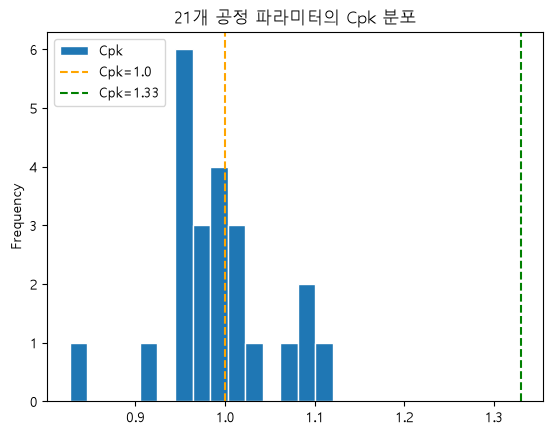

판정
부적합          15
양호(관리 필요)     8
Name: count, dtype: int64


In [3]:
capability_df["Cpk"].plot(kind="hist", bins=15, edgecolor="white")
plt.axvline(1.0, color="orange", linestyle="--", label="Cpk=1.0")
plt.axvline(1.33, color="green", linestyle="--", label="Cpk=1.33")
plt.title("21개 공정 파라미터의 Cpk 분포")
plt.legend()
plt.show()

print(capability_df["판정"].value_counts())

## 3. 관리도 예시 — 식각(Etching) 압력

프로젝트 전체에서 자주 예시로 쓴 식각 공정의 압력(pressure)을 I-MR 관리도로 그려본다.

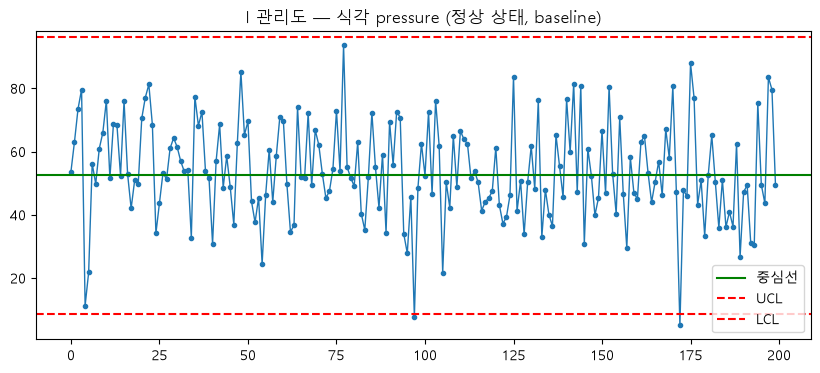

In [4]:
example_process, example_param = "etching", "pressure"
example_limits = control_limits[(example_process, example_param)]
example_values = sim.generate_batch(example_process, n_samples=N_BASELINE, anomaly_ratio=0.0)[example_param].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(example_values, marker="o", markersize=3, linewidth=1)
ax.axhline(example_limits["center"], color="green", label="중심선")
ax.axhline(example_limits["ucl"], color="red", linestyle="--", label="UCL")
ax.axhline(example_limits["lcl"], color="red", linestyle="--", label="LCL")
ax.set_title(f"I 관리도 — {PROCESS_NAMES_KO[example_process]} {example_param} (정상 상태, baseline)")
ax.legend()
plt.show()

## 4. Western Electric 룰로 이상 탐지 (baseline 관리한계를 새 데이터에 적용)

**baseline과는 별도로 새로 생성한** 데이터(이상 비율 10%, 시뮬레이터 자체 라벨 보유)에, 위에서 세운 관리한계를 그대로 적용해 Western Electric 룰로 이상을 탐지하고 ground truth와 비교한다. 관리한계를 세울 때 이 데이터를 전혀 보지 않았으므로 공정하다.

In [5]:
eval_df = sim.generate_batch(example_process, n_samples=300, anomaly_ratio=0.1)
eval_values = eval_df[example_param].to_numpy()
eval_labels = eval_df["is_anomaly"].to_numpy().astype(int)

we_flags = western_electric_flags(eval_values, example_limits["center"], example_limits["sigma_short"]).astype(int)

spc_precision = precision_score(eval_labels, we_flags, zero_division=0)
spc_recall = recall_score(eval_labels, we_flags, zero_division=0)
spc_f1 = f1_score(eval_labels, we_flags, zero_division=0)
print(f"SPC(Western Electric 룰) — precision={spc_precision:.4f} recall={spc_recall:.4f} f1={spc_f1:.4f}")

SPC(Western Electric 룰) — precision=0.6842 recall=1.0000 f1=0.8125


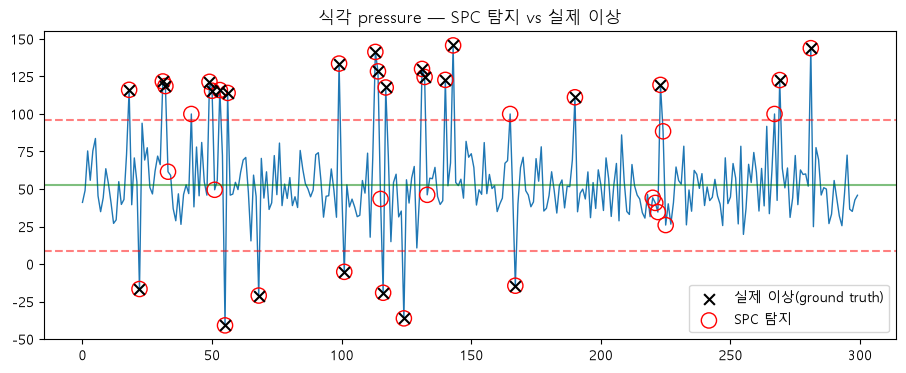

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(eval_values, linewidth=1, color="tab:blue", zorder=1)
ax.scatter(np.where(eval_labels == 1)[0], eval_values[eval_labels == 1],
           color="black", marker="x", s=60, label="실제 이상(ground truth)", zorder=3)
ax.scatter(np.where(we_flags == 1)[0], eval_values[we_flags == 1],
           facecolors="none", edgecolors="red", s=120, label="SPC 탐지", zorder=2)
ax.axhline(example_limits["center"], color="green", alpha=0.5)
ax.axhline(example_limits["ucl"], color="red", linestyle="--", alpha=0.5)
ax.axhline(example_limits["lcl"], color="red", linestyle="--", alpha=0.5)
ax.set_title(f"{PROCESS_NAMES_KO[example_process]} {example_param} — SPC 탐지 vs 실제 이상")
ax.legend()
plt.show()

## 5. 결과 저장

In [7]:
capability_df.to_csv(MODELS_DIR / "spc_capability_summary.csv", index=False)

spc_result = pd.DataFrame([{
    "process": example_process, "param": example_param,
    "precision": round(spc_precision, 4), "recall": round(spc_recall, 4), "f1": round(spc_f1, 4),
}])
spc_result.to_csv(MODELS_DIR / "spc_detection_result.csv", index=False)
print("저장 완료")

저장 완료


## 결론

**Cpk 분포**: 21개 파라미터 중 15개가 "부적합"(Cpk<1.0), 8개가 "양호(관리 필요)"(1.0~1.33), 평균 Cpk는 0.991. 시뮬레이터의 "정상" 데이터는 `(high-low)/6`을 표준편차로 써서 생성했으므로 이론상 Cpk가 1.0 근방으로 나오는 게 자연스럽다 — 실제로 딱 그렇게 나왔다. 이건 우연이 아니라 **시뮬레이터가 의도적으로 여유 없는(마진이 빠듯한) 공정을 흉내 내도록 설계됐다**는 뜻이다. 실무라면 Cpk<1.33인 파라미터는 규격을 벗어난 웨이퍼가 심심찮게 나온다는 뜻이라 관리가 필요한데, 여기서는 그게 21개 중 21개 전부에 해당한다 — 즉 시뮬레이터 기준으로는 8대 공정 전부가 "타이트하게 관리해야 하는" 상태로 세팅돼 있다.

**SPC 탐지 결과**(식각 압력, baseline과 분리된 새 데이터 300건): precision 0.684, recall **1.0**, F1 0.813. 재현율이 1.0인 이유는 명확하다 — 시뮬레이터의 이상치는 애초에 정상 범위를 10~50% 벗어나도록 규칙으로 생성되므로(`simulator/process_simulator.py`), 3시그마 관리도가 거의 다 잡아낸다. Precision이 0.68인 건 Western Electric 룰 2~4번(연속 패턴 규칙)이 정상 범위 내의 약간의 변동도 종종 신호로 잡기 때문 — 재현율을 높이는 대가로 오탐을 어느 정도 감수하는 설계다.

**SPC vs SECOM ML(XGBoost F1 0.228, notebooks/03)을 직접 비교할 순 없다** — 데이터도, 이상 발생 방식도 다르다. 하지만 이 노트북이 보여주려던 건 숫자 비교가 아니라 **관점의 차이**다: SPC는 "이 파라미터가 관리한계를 벗어났는가"라는 단순하고 설명 가능한 질문에 답하고, ML은 "590개 센서가 복합적으로 어떤 패턴을 보이는가"라는 더 어려운 질문에 답한다. 실무에서는 새 공정에는 먼저 SPC를 걸고, 데이터가 쌓이면 ML로 고도화하는 순서를 밟는 경우가 많다 — 이 노트북이 그 순서의 앞부분을 보여준다.